Data Preparation and Preliminary Analysis Report

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set()

df = pd.read_csv("C:/Users/cis101/Documents/mal_anime.csv")

df.head()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19931 entries, 0 to 19930
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   myanimelist_id   19931 non-null  int64  
 1   title            19931 non-null  object 
 2   description      19875 non-null  object 
 3   image            19544 non-null  object 
 4   Type             19534 non-null  object 
 5   Episodes         19549 non-null  object 
 6   Status           19549 non-null  object 
 7   Premiered        6343 non-null   object 
 8   Released_Season  6182 non-null   object 
 9   Released_Year    6182 non-null   float64
 10  Source           19166 non-null  object 
 11  Genres           18270 non-null  object 
 12  Themes           11217 non-null  object 
 13  Studios          19549 non-null  object 
 14  Producers        19549 non-null  object 
 15  Demographic      6522 non-null   object 
 16  Duration         19549 non-null  object 
 17  Rating      

,myanimelist_id,title,description,image,Type,Episodes,Status,Premiered,Released_Season,Released_Year,...,Demographic,Duration,Rating,Score,Ranked,Popularity,Members,Favorites,characters,source_url
count,19931.00000,19931,19875,19544,19534,19549,19549,6343,6182,6182.000000,...,6522,19549,19057,15239.000000,17406,19549,19549,19549,13519,19931
unique,NaN,19930,17393,19511,7,326,3,251,4,NaN,...,5,331,6,NaN,14645,17003,11847,1964,12835,19931
top,NaN,Shen Lan Qi Yu Wushuang Zhu: Tianmo Pian,No synopsis information has been added to this...,https://cdn.myanimelist.net/img/common/externa...,TV,1,Finished Airing,?,Spring,NaN,...,Kids,24 min. per ep.,PG-13 - Teens 13 or older,NaN,#7634,#18479,119,0,"[{""id"": 233179, ""name"": ""President"", ""url"": ""h...",https://myanimelist.net/anime/62894/Fengkuang_...
freq,NaN,2,2297,28,6343,5875,18668,161,1944,NaN,...,2825,2027,8548,NaN,3,4,30,5430,20,1
mean,29360.01726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.129893,...,NaN,NaN,NaN,6.539627,NaN,NaN,NaN,NaN,NaN,NaN
std,20509.69310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.249090,...,NaN,NaN,NaN,0.866174,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961.000000,...,NaN,NaN,NaN,1.890000,NaN,NaN,NaN,NaN,NaN,NaN
25%,7935.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005.000000,...,NaN,NaN,NaN,5.940000,NaN,NaN,NaN,NaN,NaN,NaN
50%,32559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,...,NaN,NaN,NaN,6.520000,NaN,NaN,NaN,NaN,NaN,NaN
75%,48176.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,...,NaN,NaN,NaN,7.160000,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
#Clean and convert features
df["Members"] = (
    df["Members"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["Favorites"] = (
    df["Favorites"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["Episodes"] = pd.to_numeric(df["Episodes"], errors="coerce")

df["Ranked"] = (
    df["Ranked"]
    .astype(str)
    .str.replace("#", "", regex=False)
    .astype(float)
)
df["Ranked"] = pd.to_numeric(df["Ranked"], errors="coerce")

num_cols = ["Score", "Members", "Favorites", "Episodes", 
            "Ranked", "Released_Year"]
df[num_cols].describe()

,Score,Members,Favorites,Episodes,Ranked,Released_Year
count,15239.000000,1.954900e+04,19549.000000,18872.000000,17406.000000,6182.000000
mean,6.539627,5.655706e+04,634.577472,13.637823,9571.084511,2010.129893
std,0.866174,2.014348e+05,5510.208551,43.691253,6088.051130,13.249090
min,1.890000,1.800000e+01,0.000000,1.000000,1.000000,1961.000000
25%,5.940000,6.500000e+02,0.000000,1.000000,4452.250000,2005.000000
50%,6.520000,3.690000e+03,5.000000,3.000000,8953.000000,2014.000000
75%,7.160000,2.347200e+04,51.000000,13.000000,13942.750000,2020.000000
max,9.290000,4.248837e+06,244671.000000,1818.000000,22198.000000,2027.000000


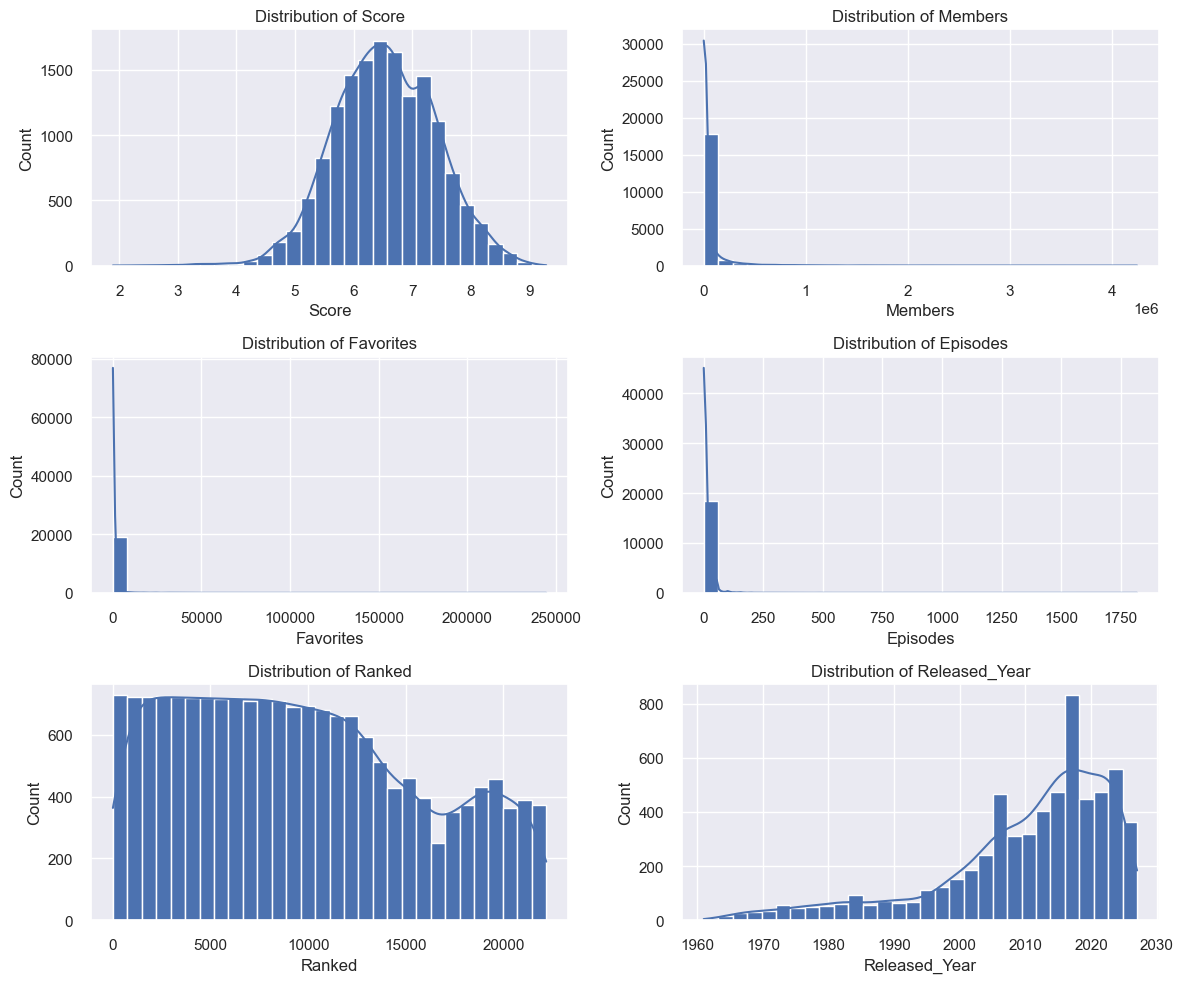

In [23]:
#Histogram for the numerical features
df[num_cols].hist(bins=30, figsize=(12, 10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

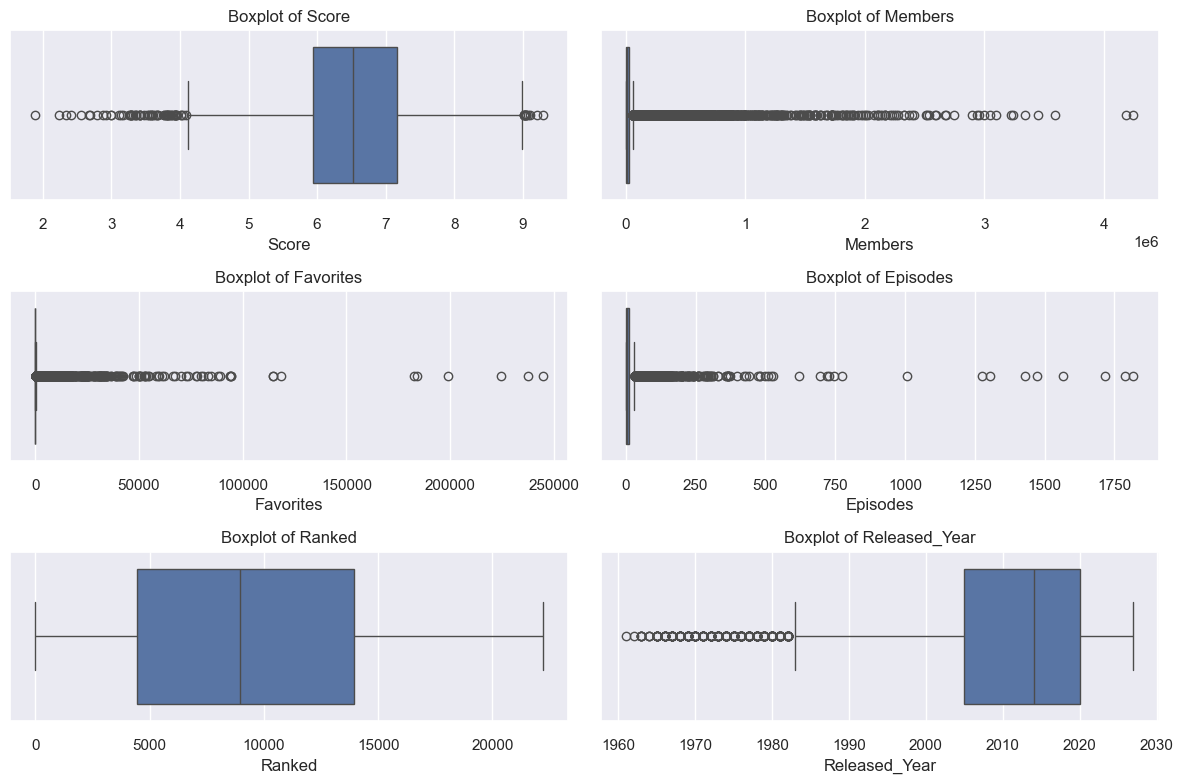

In [24]:
#Boxplots for the outliers
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

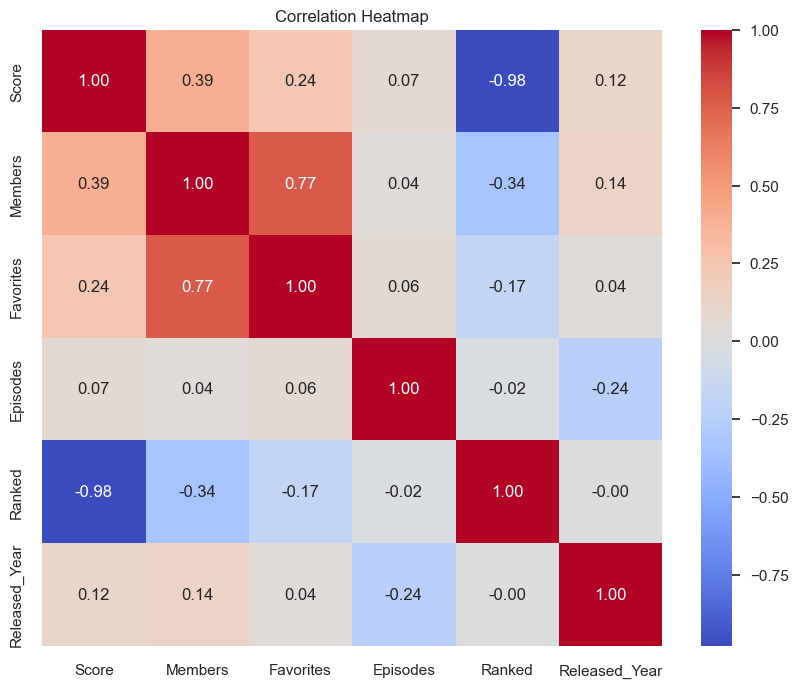

,Score,Members,Favorites,Episodes,Ranked,Released_Year
Score,1.000000,0.393411,0.241965,0.066780,-0.977837,0.116033
Members,0.393411,1.000000,0.768628,0.041387,-0.337284,0.141330
Favorites,0.241965,0.768628,1.000000,0.059925,-0.169295,0.035607
Episodes,0.066780,0.041387,0.059925,1.000000,-0.019496,-0.239473
Ranked,-0.977837,-0.337284,-0.169295,-0.019496,1.000000,-0.002563
Released_Year,0.116033,0.141330,0.035607,-0.239473,-0.002563,1.000000


In [25]:
#Correlation Matrix
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

corr

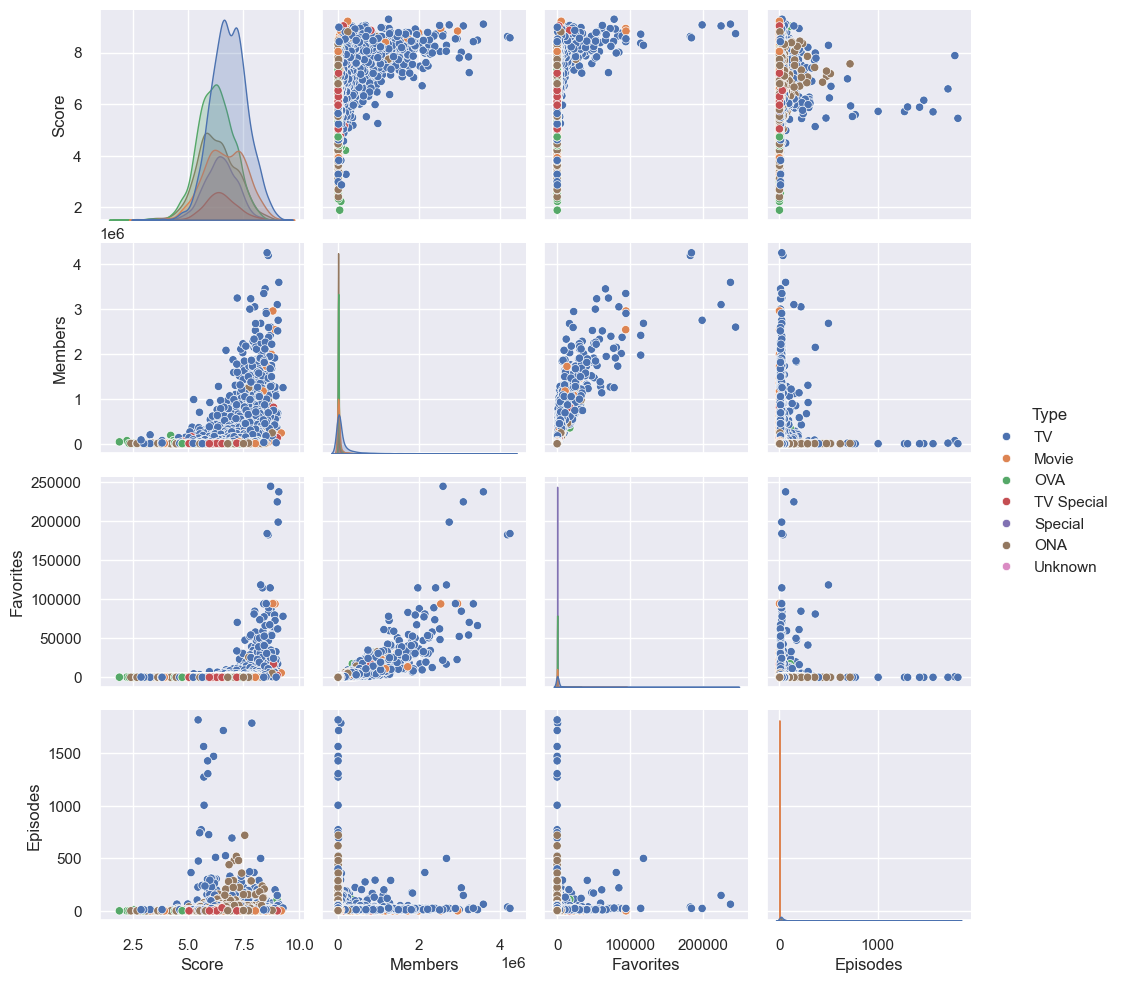

In [15]:
#Pair Plot
pair_cols=["Score", "Members", "Favorites",
           "Episodes", "Type"]

sns.pairplot(df[pair_cols], hue="Type", diag_kind="kde")
plt.show()

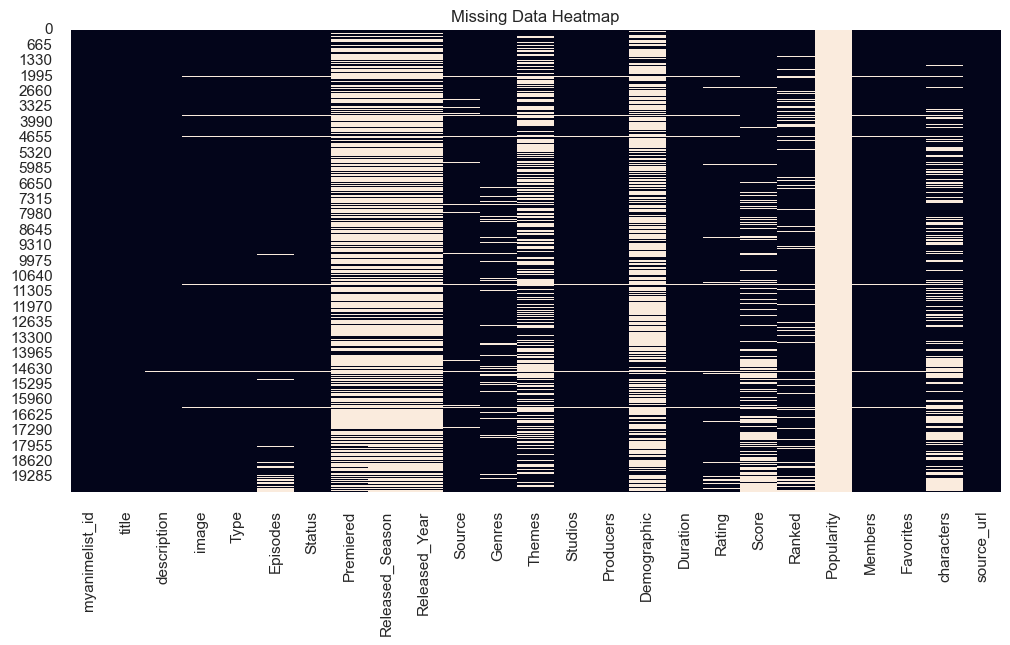

In [26]:
#Missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

In [29]:
#Data preprocessing 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


#redifinning num and cat columns
num_cols = [ "Score", "Members", "Favorites", "Episodes", "Ranked", "Released_Year"]
cat_cols = [ "Type", "Rating", "Source"]

#Handle missing values
df_clean = df.copy()

#Impute with meadian (numeric columns)
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

#impute with mode (categorical columns)
cat_cols = ["Type", "Rating", "Source"]
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

#one-hot encode for cat features
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

#scale num features
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

#PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(df_encoded[num_cols])

print("Original shape:", df_encoded.shape)
print("PCA shape:", X_pca.shape)

Original shape: (19931, 49)
PCA shape: (19931, 5)


In [33]:
#Final feature set

final_num_cols = [ "Score", "Members", "Favorites", "Episodes",
                  "Ranked", "Released_Year"]
df_encoded[final_num_cols + 
            [col for col in df_encoded.columns if col not in final_num_cols and col.startswith(("Type_", "Rating_", "Source_"))]
            ].head()

,Score,Members,Favorites,Episodes,Ranked,Released_Year,Type_ONA,Type_OVA,Type_Special,Type_TV,...,Source_Music,Source_Novel,Source_Original,Source_Other,Source_Picture book,Source_Radio,Source_Unknown,Source_Visual novel,Source_Web manga,Source_Web novel
0,2.924433,9.780877,15.994581,0.303599,-1.659043,-1.949298,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
1,2.435926,1.743599,0.206221,-0.283524,-1.626723,0.158107,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,2.224679,3.805179,3.036172,0.303599,-1.599847,-1.949298,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,0.917593,0.352287,0.011633,0.303599,-1.080077,-1.422447,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,0.508303,-0.195809,-0.110763,0.914208,-0.809038,-1.159021,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
